# Lab 2: Number Detection

## 1. Imports and paths

In [30]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from IPython.display import Markdown, display
from ultralytics import YOLO

cwd = Path.cwd()
lab2_dir = cwd if (cwd / 'main.py').exists() and (cwd / 'config').exists() else cwd / 'lab2'

svhn_yaml = lab2_dir / 'config' / 'svhn32.yaml'
roboflow_yaml = lab2_dir / 'config' / 'svhn.yaml'
metrics_path = lab2_dir / 'runs' / 'eval_metrics_svhn32.json'
photos_dir = lab2_dir / 'photos'

svhn_model = lab2_dir / 'runs' / 'detect' / 'runs' / 'svhn32_yolos' / 'weights' / 'best.pt'
model_path = lab2_dir / 'runs' / 'detect' / 'runs' / 'svhn32_yolos_plus_roboflow' / 'weights' / 'best.pt'
finetune_results = lab2_dir / 'runs' / 'detect' / 'runs' / 'svhn32_yolos_plus_roboflow' / 'results.csv'

print(f'lab2_dir: {lab2_dir}')
print(f'SVHN config: {svhn_yaml}')
print(f'Roboflow config: {roboflow_yaml}')
print(f'SVHN metrics: {metrics_path}')
print(f'SVHN model: {svhn_model}')
print(f'Final model: {model_path}')
print(f'Photos: {photos_dir}')

assert svhn_yaml.exists(), f'Missing SVHN config: {svhn_yaml}'
assert roboflow_yaml.exists(), f'Missing Roboflow config: {roboflow_yaml}'
assert metrics_path.exists(), f'Missing metrics file: {metrics_path}'
assert svhn_model.exists(), f'Missing SVHN model weights: {svhn_model}'
assert model_path.exists(), f'Missing fine-tuned model weights: {model_path}'
assert photos_dir.exists(), f'Missing photos directory: {photos_dir}'

lab2_dir: T:\itmo\cv\cv_labs\lab2
SVHN config: T:\itmo\cv\cv_labs\lab2\config\svhn32.yaml
Roboflow config: T:\itmo\cv\cv_labs\lab2\config\svhn.yaml
SVHN metrics: T:\itmo\cv\cv_labs\lab2\runs\eval_metrics_svhn32.json
SVHN model: T:\itmo\cv\cv_labs\lab2\runs\detect\runs\svhn32_yolos\weights\best.pt
Final model: T:\itmo\cv\cv_labs\lab2\runs\detect\runs\svhn32_yolos_plus_roboflow\weights\best.pt
Photos: T:\itmo\cv\cv_labs\lab2\photos


## 2. Datasets and model

- Main dataset: official The Street View House Numbers, files `train_32x32.mat` and `test_32x32.mat`.
- SVHN data was converted to YOLO format with `prepare-svhn32`.
- Additional dataset: Roboflow number-detection dataset in YOLO format.
- Base model: YOLOv8s trained on SVHN.
- Final model: SVHN weights fine-tuned on Roboflow.
- Prediction cells use `runs/detect/runs/svhn32_yolos_plus_roboflow/weights/best.pt`.

In [31]:
print('SVHN config')
print(svhn_yaml.read_text(encoding='utf-8'))
print('Roboflow config')
print(roboflow_yaml.read_text(encoding='utf-8'))

SVHN config
path: T:/itmo/cv/cv_labs/lab2/data/svhn32-yolo
train: train/images
val: valid/images
test: test/images

nc: 10
names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Roboflow config
path: T:/itmo/cv/cv_labs/lab2/data/roboflow-number-detection
train: train/images
val: valid/images
test: test/images

nc: 10
names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']



## 3. SVHN dataset examples

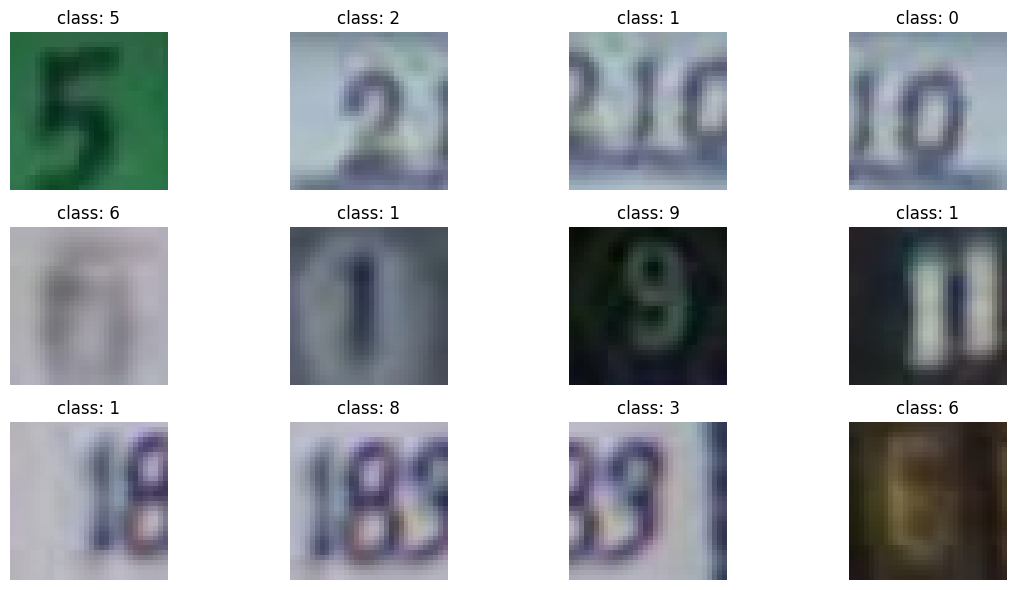

In [32]:
sample_image_dir = lab2_dir / 'data' / 'svhn32-yolo' / 'test' / 'images'
sample_label_dir = lab2_dir / 'data' / 'svhn32-yolo' / 'test' / 'labels'

sample_paths = sorted(sample_image_dir.glob('*.png'))[:12]
assert sample_paths, f'Missing SVHN images: {sample_image_dir}'

plt.figure(figsize=(12, 6))
for i, image_path in enumerate(sample_paths, start=1):
    label_path = sample_label_dir / f'{image_path.stem}.txt'
    cls_id = label_path.read_text(encoding='utf-8').split()[0]
    ax = plt.subplot(3, 4, i)
    ax.imshow(Image.open(image_path))
    ax.set_title(f'class: {cls_id}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Roboflow dataset examples

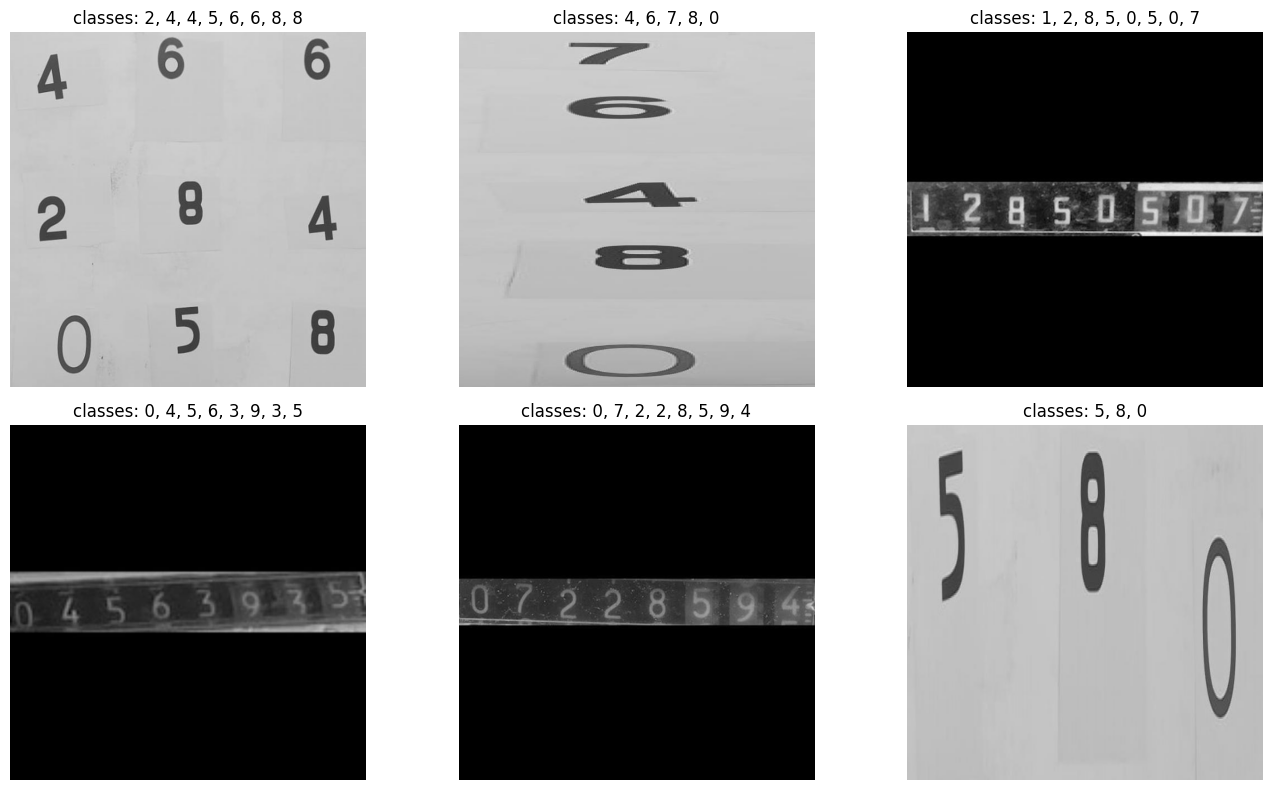

In [33]:
roboflow_image_dir = lab2_dir / 'data' / 'roboflow-number-detection' / 'test' / 'images'
roboflow_label_dir = lab2_dir / 'data' / 'roboflow-number-detection' / 'test' / 'labels'

roboflow_paths = sorted(roboflow_image_dir.glob('*.*'))[:6]
assert roboflow_paths, f'Missing Roboflow images: {roboflow_image_dir}'

plt.figure(figsize=(14, 8))
for i, image_path in enumerate(roboflow_paths, start=1):
    label_path = roboflow_label_dir / f'{image_path.stem}.txt'
    labels = label_path.read_text(encoding='utf-8').splitlines() if label_path.exists() else []
    classes = [line.split()[0] for line in labels if line.strip()]
    ax = plt.subplot(2, 3, i)
    ax.imshow(Image.open(image_path))
    ax.set_title('classes: ' + ', '.join(classes[:8]))
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Test metrics on SVHN

In [34]:
metrics = json.loads(metrics_path.read_text(encoding='utf-8'))

rows = [
    ('Precision', metrics.get('precision')),
    ('Recall', metrics.get('recall')),
    ('mAP@0.5', metrics.get('map50')),
    ('mAP@0.5:0.95', metrics.get('map50_95')),
    ('Mean best IoU', metrics.get('mean_best_iou')),
]

table = '| Metric | Value |\n| --- | ---: |\n'
for name, value in rows:
    table += f'| {name} | {value:.4f} |\n' if value is not None else f'| {name} | n/a |\n'

display(Markdown(table))

if metrics.get('map50_95', 0) >= 0.6:
    display(Markdown('**Conclusion:** `mAP@0.5:0.95 >= 0.6`, so the requirement is satisfied.'))
else:
    display(Markdown('**Conclusion:** the mAP requirement is not satisfied yet.'))

| Metric | Value |
| --- | ---: |
| Precision | 0.9750 |
| Recall | 0.9630 |
| mAP@0.5 | 0.9884 |
| mAP@0.5:0.95 | 0.9801 |
| Mean best IoU | 0.9990 |


**Conclusion:** `mAP@0.5:0.95 >= 0.6`, so the requirement is satisfied.

## 6. Roboflow fine-tuning run

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
72,73,3335.45,0.93970,0.43110,1.17330,0.98543,0.97281,0.99221,0.69612,1.11163,0.45174,1.26839,0.000078,0.000078,0.000078
73,74,3384.61,0.93056,0.42919,1.15260,0.98009,0.97588,0.99220,0.70237,1.10140,0.45140,1.26121,0.000069,0.000069,0.000069
74,75,3436.99,0.92144,0.42432,1.14815,0.98755,0.96694,0.99216,0.69861,1.09716,0.44958,1.26154,0.000060,0.000060,0.000060


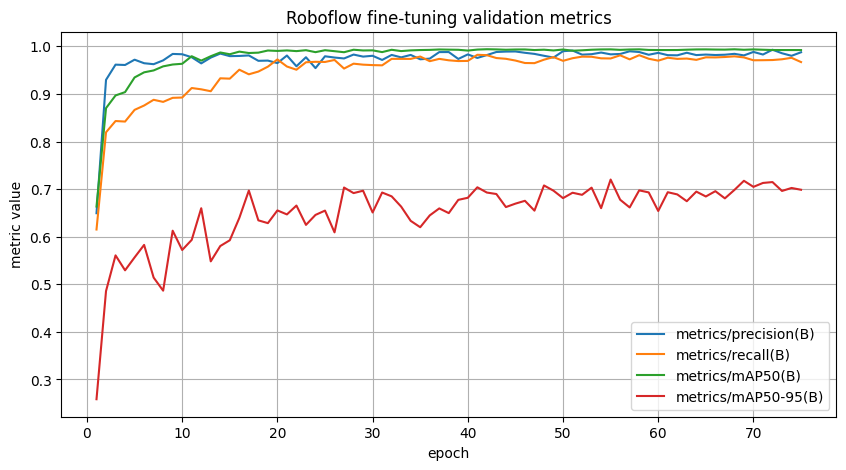

In [35]:
assert finetune_results.exists(), f'Missing fine-tuning results: {finetune_results}'
df = pd.read_csv(finetune_results)
df.columns = [c.strip() for c in df.columns]
last = df.iloc[-1]

display(df.tail(3))

metric_cols = [c for c in ['metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)'] if c in df.columns]
if metric_cols:
    ax = df.plot(x='epoch', y=metric_cols, figsize=(10, 5), grid=True)
    ax.set_title('Roboflow fine-tuning validation metrics')
    ax.set_xlabel('epoch')
    ax.set_ylabel('metric value')
    plt.show()

## 7. Load fine-tuned model

In [36]:
model = YOLO(str(model_path))
print(model_path)
print(model.names)

T:\itmo\cv\cv_labs\lab2\runs\detect\runs\svhn32_yolos_plus_roboflow\weights\best.pt
{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9'}


## 8. Prediction on local photos

In [37]:
image_paths = sorted([
    p for p in photos_dir.iterdir()
    if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
])

print(f'Found photos: {len(image_paths)}')
for p in image_paths[:10]:
    print('-', p.name)

assert image_paths, 'No images found in lab2/photos.'

results = model.predict(
    source=str(photos_dir),
    imgsz=640,
    conf=0.25,
    iou=0.7,
    save=True,
    save_txt=True,
    save_conf=True,
    project=str(lab2_dir / 'runs'),
    name='demo_notebook_predictions',
    exist_ok=True,
)

pred_dir = Path(results[0].save_dir) if results else lab2_dir / 'runs' / 'detect' / 'demo_notebook_predictions'
print(f'Prediction directory: {pred_dir}')

Found photos: 30
- IMG_20260526_203106.jpg
- IMG_20260526_203116.jpg
- IMG_20260526_203125.jpg
- IMG_20260526_203132.jpg
- IMG_20260526_203149.jpg
- IMG_20260526_203203.jpg
- IMG_20260526_203304.jpg
- IMG_20260526_203311.jpg
- IMG_20260526_203413.jpg
- IMG_20260526_203503.jpg

image 1/30 T:\itmo\cv\cv_labs\lab2\photos\IMG_20260526_203106.jpg: 480x640 2 0s, 4 4s, 1 6, 1 7, 22.2ms
image 2/30 T:\itmo\cv\cv_labs\lab2\photos\IMG_20260526_203116.jpg: 640x480 (no detections), 22.5ms
image 3/30 T:\itmo\cv\cv_labs\lab2\photos\IMG_20260526_203125.jpg: 480x640 1 0, 2 1s, 1 3, 1 4, 2 6s, 1 7, 2 8s, 20.5ms
image 4/30 T:\itmo\cv\cv_labs\lab2\photos\IMG_20260526_203132.jpg: 480x640 1 8, 16.1ms
image 5/30 T:\itmo\cv\cv_labs\lab2\photos\IMG_20260526_203149.jpg: 480x640 1 0, 3 1s, 1 3, 1 6, 2 7s, 1 8, 22.2ms
image 6/30 T:\itmo\cv\cv_labs\lab2\photos\IMG_20260526_203203.jpg: 480x640 3 2s, 1 4, 17.4ms
image 7/30 T:\itmo\cv\cv_labs\lab2\photos\IMG_20260526_203304.jpg: 640x480 (no detections), 19.3ms
image 

## 9. Prediction visualization

Prediction directory: T:\itmo\cv\cv_labs\lab2\runs\demo_notebook_predictions


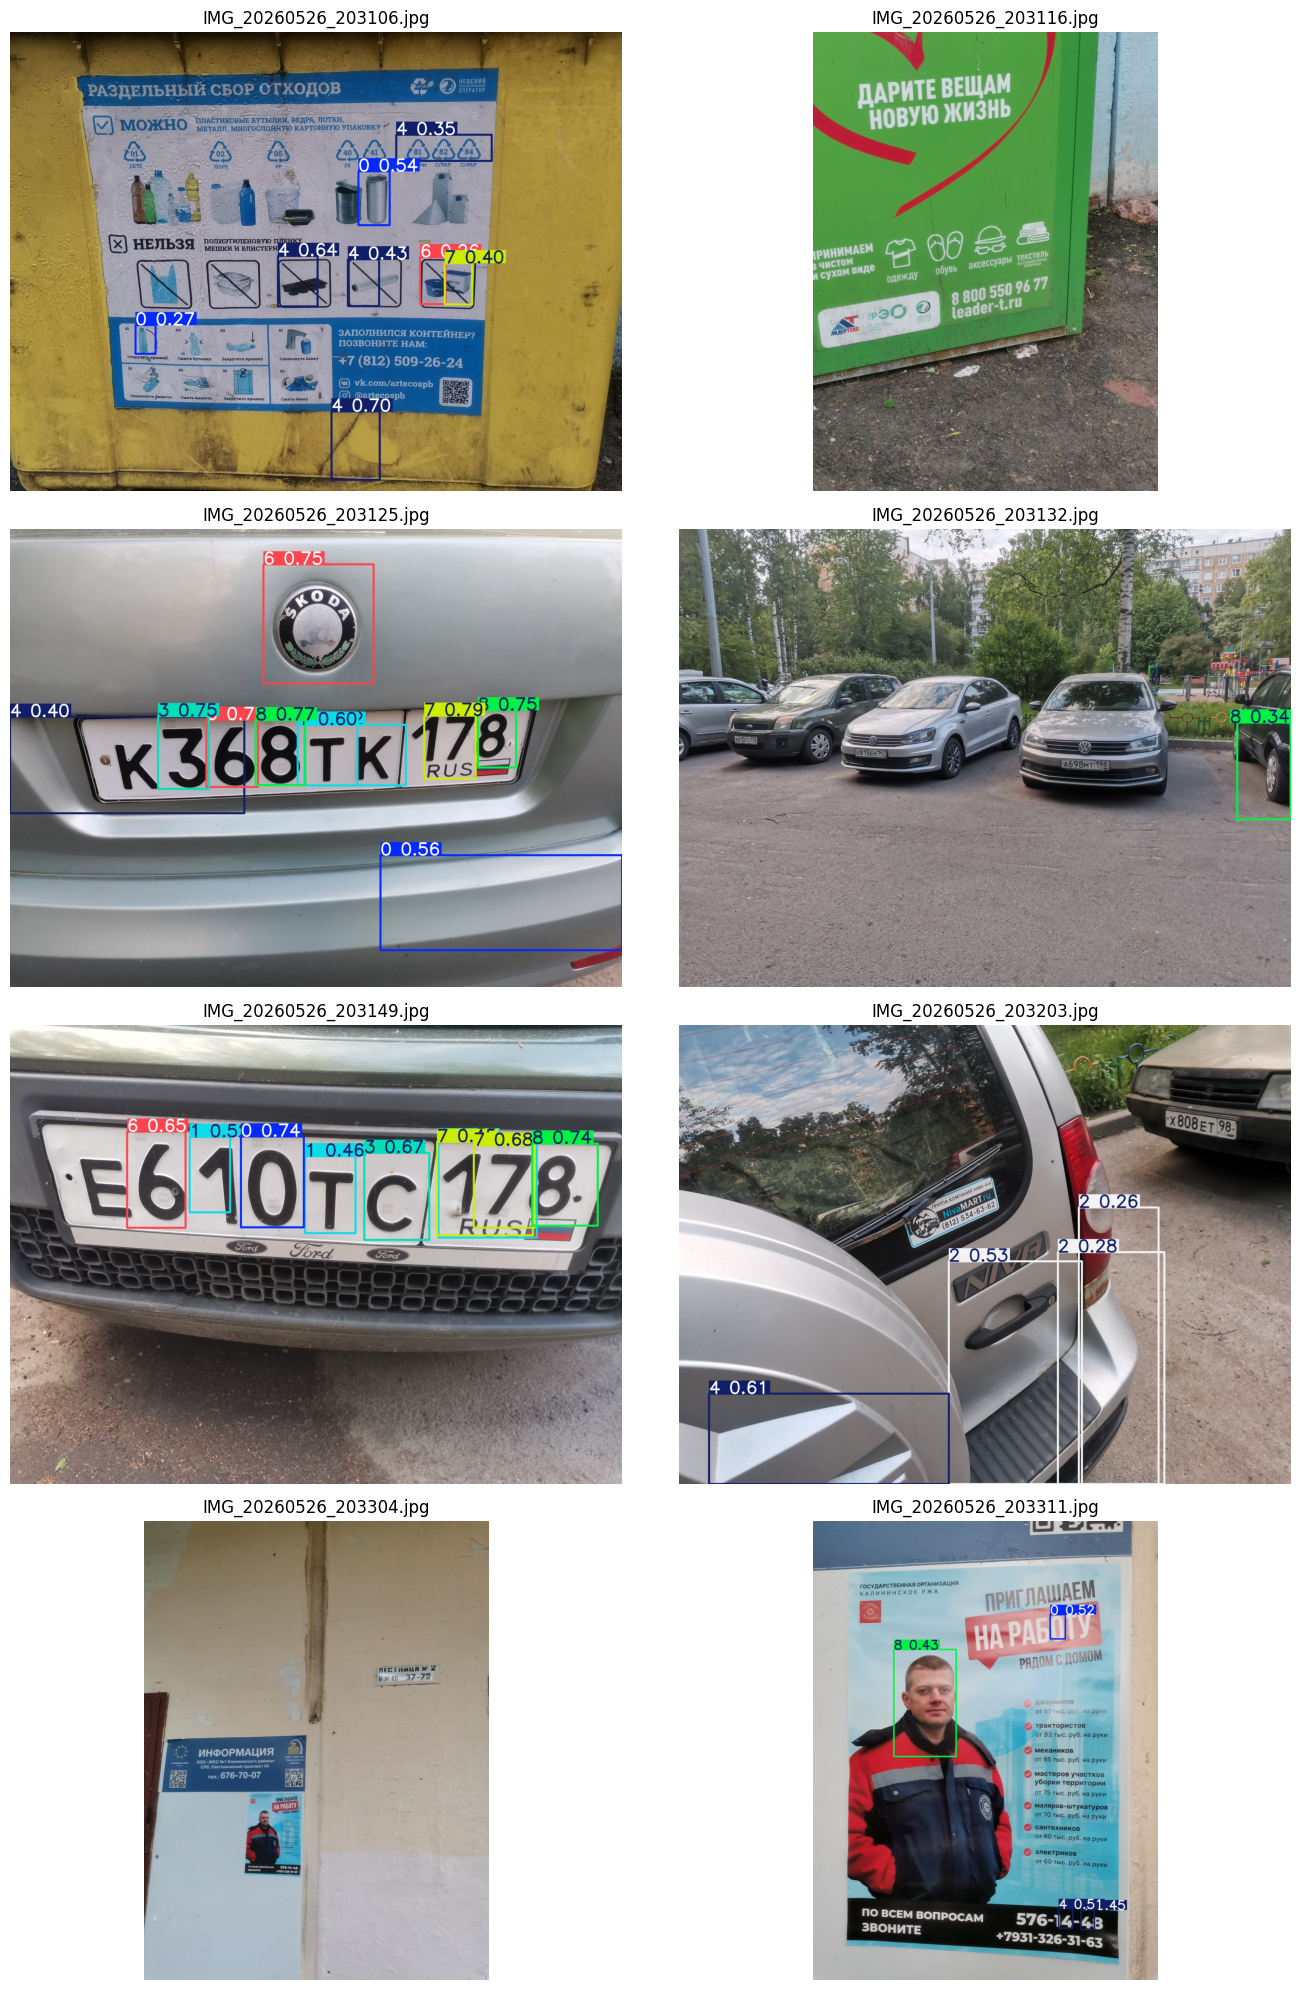

In [38]:
if 'pred_dir' not in globals() or not pred_dir.exists():
    preferred_names = [
        'demo_notebook_predictions',
        'street_photos_roboflow',
        'street_photos_final',
        'street_photos_svhn32',
        'street_photos',
    ]
    candidates = []
    detect_root = lab2_dir / 'runs' / 'detect'
    if detect_root.exists():
        for name in preferred_names:
            candidates.extend([p for p in detect_root.rglob(name) if p.is_dir()])
    candidates = [
        p for p in candidates
        if any(f.suffix.lower() in {'.jpg', '.jpeg', '.png'} for f in p.iterdir())
    ]
    assert candidates, 'Run the prediction cell first.'
    pred_dir = max(candidates, key=lambda p: p.stat().st_mtime)

print(f'Prediction directory: {pred_dir}')

pred_images = sorted([
    p for p in pred_dir.iterdir()
    if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}
])

assert pred_images, f'No prediction images found in {pred_dir}.'

show_count = min(8, len(pred_images))
cols = 2
rows = (show_count + cols - 1) // cols

plt.figure(figsize=(14, 5 * rows))
for i, path in enumerate(pred_images[:show_count], start=1):
    image = Image.open(path)
    ax = plt.subplot(rows, cols, i)
    ax.imshow(image)
    ax.set_title(path.name)
    ax.axis('off')
plt.tight_layout()
plt.show()